In [ ]:
!pip install -q textblob wordcloud imageio requests
import nltk
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import requests
import imageio
import matplotlib.pyplot as plt
import pandas as pd
from textblob import TextBlob
from nltk.corpus import stopwords
from wordcloud import WordCloud
from collections import Counter

In [ ]:
target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(target_url)
data = response.text

blob = TextBlob(data)

In [ ]:
stop_words = stopwords.words('english')
words = [
    word.lower()
    for word in blob.words
    if word.isalpha() and word.lower() not in stop_words
]

word_counts = Counter(words)
top20 = word_counts.most_common(20)
print(top20)

[('ham', 337), ('lord', 211), ('haue', 175), ('king', 173), ('shall', 107), ('come', 106), ('thou', 105), ('let', 104), ('hamlet', 100), ('good', 98), ('hor', 95), ('thy', 90), ('enter', 85), ('oh', 81), ('like', 78), ('well', 70), ('may', 69), ('know', 69), ('selfe', 68), ('would', 68)]


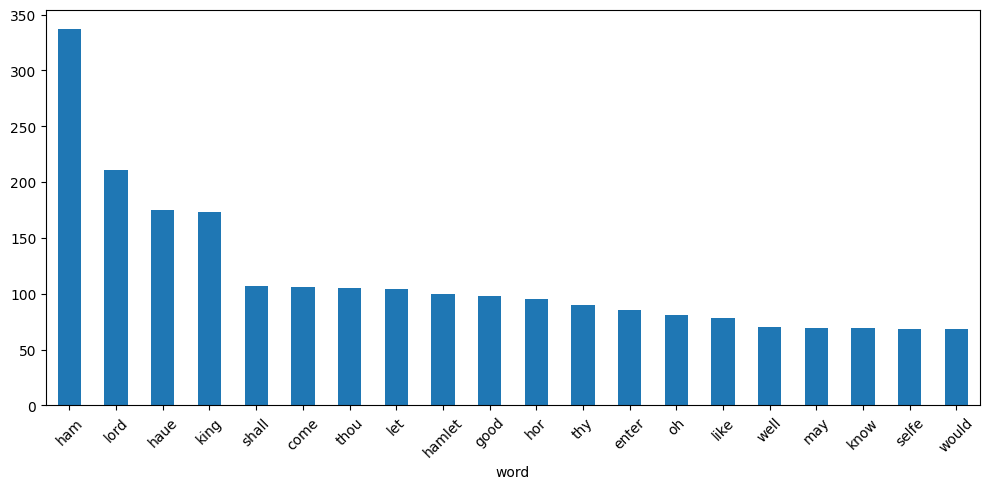

In [ ]:
df = pd.DataFrame(top20, columns=['word', 'count'])
df.plot.bar(x='word', y='count', legend=False, figsize=(10, 5))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
image_file = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"
mask_image = imageio.v3.imread(image_file)

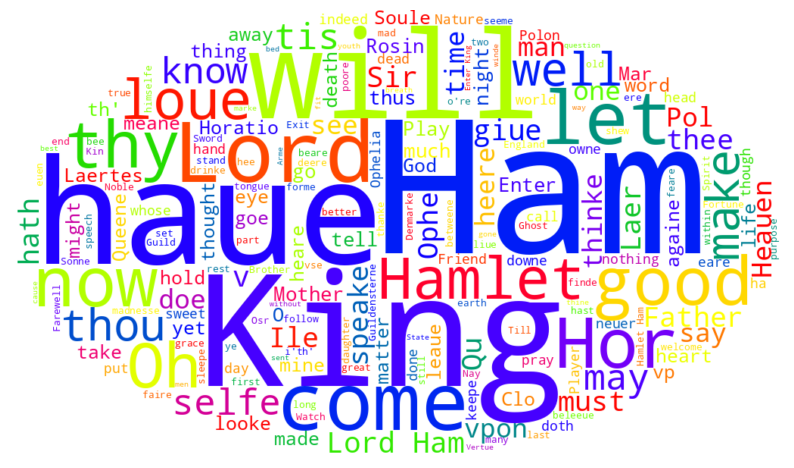

In [ ]:
word_cloud = WordCloud(width=1000, height=1000,
                       colormap='prism',
                       mask=mask_image,
                       background_color='white').generate(data)

plt.figure(figsize=(10, 10))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()